In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# SETTING UP NECESSARY LIBRARIES

In [2]:
!pip install -q datasets huggingface_hub
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 93.8 MB/s eta 0:00:00


# Loading the Data

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "mrdbourke/FoodExtract-1k-Vision"
)

dataset

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1510 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image_name', 'food101_class_name', 'food101_split', 'image_source', 'qwen3_vl_8b_yaml_out', 'qwen3_vl_inference_time', 'output_label_json', 'is_food', 'image'],
        num_rows: 1510
    })
})

# **Inspecting The Data Content**

Dataset({
    features: ['image_id', 'image_name', 'food101_class_name', 'food101_split', 'image_source', 'qwen3_vl_8b_yaml_out', 'qwen3_vl_inference_time', 'output_label_json', 'is_food', 'image'],
    num_rows: 1510
})

Columns:
['image_id', 'image_name', 'food101_class_name', 'food101_split', 'image_source', 'qwen3_vl_8b_yaml_out', 'qwen3_vl_inference_time', 'output_label_json', 'is_food', 'image']
Number of samples: 1510

Food distribution:
is_food
1    1010
0     500
Name: count, dtype: int64

Image sources:
image_source
food101     1010
manual       250
internet     250
Name: count, dtype: int64

Food101 splits:
food101_split
train    757
test     253
Name: count, dtype: int64
Image ID: 3233632
Image name: 3233632.jpg
Food101 class: cheese_plate
Food101 split: train
Source: food101
Is food: 1

Qwen output:
point_of_view: 45-degree
dishes:
  - cheese plate
food_items:
  - cheese wedge
  - toast
  - herb garnish
  - dipping sauce
drink_items: []
containers_and_utensils:
  - white p

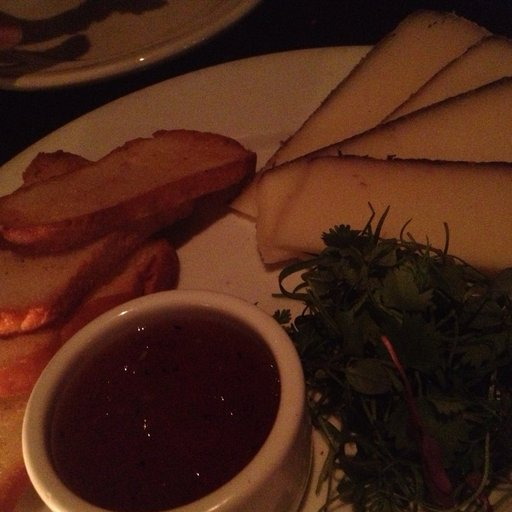

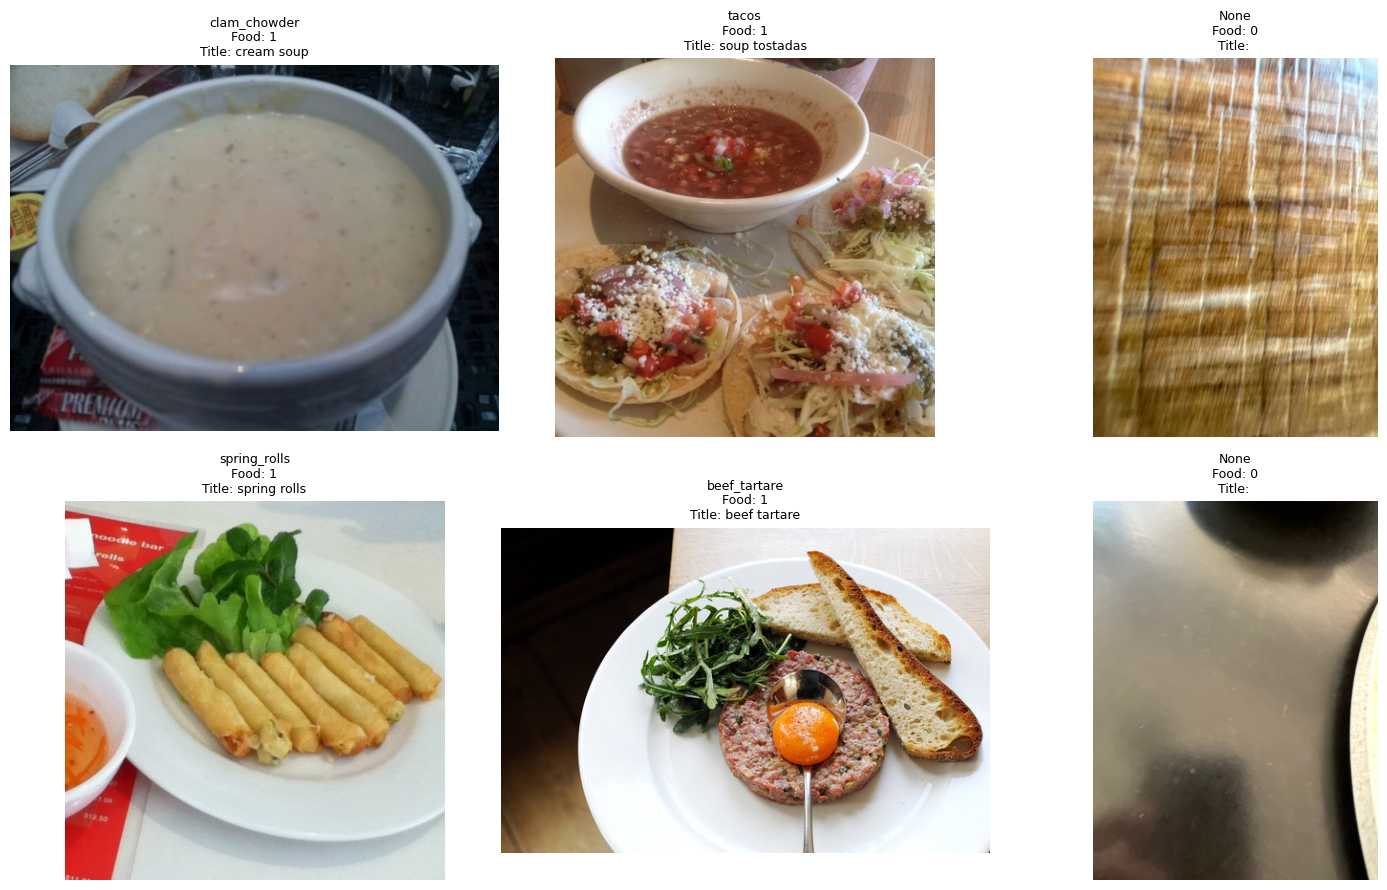

Class: clam_chowder
Label: {'is_food': 1, 'image_title': 'cream soup', 'food_items': ['cream', 'diced vegetables', 'broth'], 'drink_items': []}
Class: tacos
Label: {'is_food': 1, 'image_title': 'soup tostadas', 'food_items': ['meat (likely pork or fish)', 'onion', 'crumbled cheese', 'shredded cabbage', 'tortilla', 'salsa', 'cilantro', 'diced tomato'], 'drink_items': []}
Class: None
Label: {'is_food': 0, 'image_title': '', 'food_items': [], 'drink_items': []}
Class: spring_rolls
Label: {'is_food': 1, 'image_title': 'spring rolls', 'food_items': ['lettuce leaf', 'fried spring roll'], 'drink_items': ['dipping sauce']}
Class: beef_tartare
Label: {'is_food': 1, 'image_title': 'beef tartare', 'food_items': ['bread', 'arugula', 'beef patty', 'raw egg yolk'], 'drink_items': []}
Class: None
Label: {'is_food': 0, 'image_title': '', 'food_items': [], 'drink_items': []}


In [4]:
ds = dataset["train"]

print(ds)
print("\nColumns:")
print(ds.column_names)

print("Number of samples:", len(ds))

print("\nFood distribution:")
print(ds.to_pandas()["is_food"].value_counts())

print("\nImage sources:")
print(ds.to_pandas()["image_source"].value_counts())

print("\nFood101 splits:")
print(ds.to_pandas()["food101_split"].value_counts())


df = ds.to_pandas()

df.head()


sample = ds[0]

print("Image ID:", sample["image_id"])
print("Image name:", sample["image_name"])
print("Food101 class:", sample["food101_class_name"])
print("Food101 split:", sample["food101_split"])
print("Source:", sample["image_source"])
print("Is food:", sample["is_food"])

print("\nQwen output:")
print(sample["qwen3_vl_8b_yaml_out"])

print("\nStructured label:")
print(sample["output_label_json"])

print("\nImage:")
display(sample["image"])


import matplotlib.pyplot as plt
import random

indices = random.sample(range(len(ds)), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, idx in zip(axes.flat, indices):
    sample = ds[idx]

    ax.imshow(sample["image"])
    ax.axis("off")

    label = sample["output_label_json"]

    title = (
        f"{sample['food101_class_name']}\n"
        f"Food: {label['is_food']}\n"
        f"Title: {label['image_title']}"
    )

    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

for idx in indices:
    sample = ds[idx]
    
    print("=" * 80)
    print("Class:", sample["food101_class_name"])
    print("Label:", sample["output_label_json"])

# VLM Model Candiates

We consider the following **open-weight Vision-Language Models** (VLMs) for our Feast_Vision

| Model | Parameters | Key Strength |
|---|---:|---|
| Qwen2.5-VL-3B | ~3B | Strong visual reasoning |
| Qwen2.5-VL-7B | ~7B | Strong overall capability |
| **SmolVLM-500M-Instruct** | ~500M | Lightweight and efficient |
| InternVL2.5-4B | ~4B | Strong multimodal understanding |
| LLaVA-1.5-7B | ~7B | Mature VLM ecosystem |

### Selected Model: SmolVLM-500M-Instruct

We select **SmolVLM-500M-Instruct** as our primary model because it provides
a strong **capability-to-compute trade-off**.

Its small size makes is suitable for:

- Low-cost inference and deployment
- Lower GPU (our main limitaion)
- Lower inference latency
- Efficient fine-tuning
- Potential edge on consumer-device deployment

# Setting Up the SmolVLM

In [5]:
import torch
from transformers import AutoProcessor, AutoModelForMultimodalLM

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

model.eval()

print("Model loaded successfully!")

Device: cuda


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Model loaded successfully!


# Experimetining with base SmolVLM



Image:


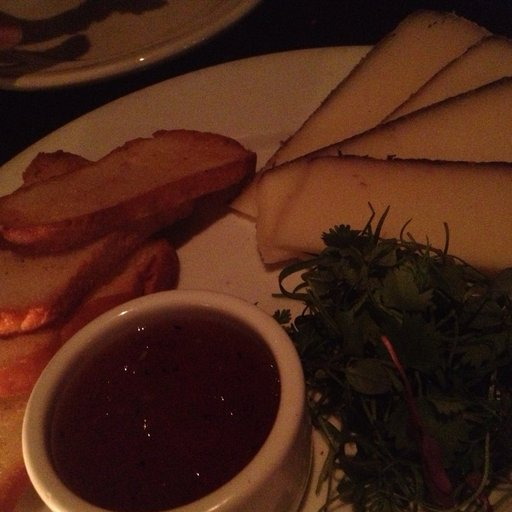

In [6]:
sample = ds[0]
print("\nImage:")
display(sample["image"])

# Prompt Methodology and Its Effect on VLM Performance

** Objective**

To understand how prompt formulation affects the performance of the VLM, three
prompting methodologies were evaluated on the same image:

1. **Normal / Direct Prompting**
2. **Descriptive / Constrained Prompting**
3. **Chain-of-Thought (CoT)-style Prompting**

The objective was to determine whether increasing the level of instruction and
reasoning improves the model's ability to identify the food items actually
present in the image.

**Reference Ground Truth**

The structured reference label for the image is:

```text
is_food: 1
image_title: cheese plate
food_items:
    - toast
    - herb garnish
    - dipping sauce
    - cheese wedge
drink_items: []

## 1.Normal Prompting

In [7]:

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": """Look carefully at this image.

Is there food in the image?
What food items can you identify?

Return:
is_food: yes/no
food_items: item1, item2, item3
"""
            }
        ]
    }
]

# Create prompt
prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

# Prepare inputs
inputs = processor(
    text=prompt,
    images=[sample["image"]],
    return_tensors="pt"
)

# Move tensors to GPU
inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

# Generate
with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

# IMPORTANT: decode full output first
generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("===== MODEL OUTPUT =====")
print(generated_text)

===== MODEL OUTPUT =====
User:




Look carefully at this image.

Is there food in the image?
What food items can you identify?

Return:
is_food: yes/no
food_items: item1, item2, item3

Assistant: Yes.


## 2.Descriptive  Prompting

In [8]:
sample = ds[0]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": "You are analyzing a food image.Identify the food items that are clearly visible in the image.Return ONLY a comma-separated list of food items.Do not describe the image.Do not mention plates, bowls, utensils, or decorations."
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[sample["image"]],
    return_tensors="pt"
)

inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

output = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print(output)

User:




You are analyzing a food image.Identify the food items that are clearly visible in the image.Return ONLY a comma-separated list of food items.Do not describe the image.Do not mention plates, bowls, utensils, or decorations.
Assistant: Fries.


## 3.Chain of Thought Prompting method

In [9]:
sample = ds[0]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": "You are analyzing a food image. Use chain of thought methodology before coming up any conclusion.Identify the food items that are clearly visible in the image.Return ONLY a comma-separated list of food items.Do not describe the image.Do not mention plates, bowls, utensils, or decorations."
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[sample["image"]],
    return_tensors="pt"
)

inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

output = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print(output)

User:




You are analyzing a food image. Use chain of thought methodology before coming up any conclusion.Identify the food items that are clearly visible in the image.Return ONLY a comma-separated list of food items.Do not describe the image.Do not mention plates, bowls, utensils, or decorations.
Assistant: Bacon, Parsley, Sauce.


## Conclusion

Even with **strong prompting strategies** like direct, constrained and CoT-style 
the VLM fails to reliably identify the correct food items.

The model shows two key failure modes:

- **Missed items:** fails to detect food items that are actually present.
- **Hallucination:** generates plausible but visually unsupported items such as
  `fries`, `bacon`, and `parsley`.

This indicates that the limitation is not simply prompt quality but **weak
visual grounding**. Therefore, improving performance requires
moving beyond prompt engineering

In [10]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU capability:", torch.cuda.get_device_capability(0))
!nvidia-smi

    

PyTorch: 2.10.0+cu128
CUDA available: True
PyTorch CUDA: 12.8
GPU: Tesla T4
GPU capability: (7, 5)
Wed Sep  2 12:52:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P0             34W /   70W |    3073MiB /  15360MiB |      0%      Default |
|                                        